In [ ]:
import os

os.listdir('/content')

['.config', 'job_descriptions.csv', 'sample_data']

In [ ]:
import pandas as pd

df = pd.read_csv('/content/job_descriptions.csv')

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (78705, 23)

Columns:
['Job Id', 'Experience', 'Qualifications', 'Salary Range', 'location', 'Country', 'latitude', 'longitude', 'Work Type', 'Company Size', 'Job Posting Date', 'Preference', 'Contact Person', 'Contact', 'Job Title', 'Role', 'Job Portal', 'Job Description', 'Benefits', 'skills', 'Responsibilities', 'Company', 'Company Profile']


,Job Id,Experience,Qualifications,Salary Range,location,Country,latitude,longitude,Work Type,Company Size,...,Contact,Job Title,Role,Job Portal,Job Description,Benefits,skills,Responsibilities,Company,Company Profile
0,1089843540111562,5 to 15 Years,M.Tech,$59K-$99K,Douglas,Isle of Man,54.2361,-4.5481,Intern,26801,...,001-381-930-7517x737,Digital Marketing Specialist,Social Media Manager,Snagajob,Social Media Managers oversee an organizations...,"{'Flexible Spending Accounts (FSAs), Relocatio...","Social media platforms (e.g., Facebook, Twitte...","Manage and grow social media accounts, create ...",Icahn Enterprises,"{""Sector"":""Diversified"",""Industry"":""Diversifie..."
1,398454096642776,2 to 12 Years,BCA,$56K-$116K,Ashgabat,Turkmenistan,38.9697,59.5563,Intern,100340,...,461-509-4216,Web Developer,Frontend Web Developer,Idealist,Frontend Web Developers design and implement u...,"{'Health Insurance, Retirement Plans, Paid Tim...","HTML, CSS, JavaScript Frontend frameworks (e.g...","Design and code user interfaces for websites, ...",PNC Financial Services Group,"{""Sector"":""Financial Services"",""Industry"":""Com..."
2,481640072963533,0 to 12 Years,PhD,$61K-$104K,Macao,"Macao SAR, China",22.1987,113.5439,Temporary,84525,...,9687619505,Operations Manager,Quality Control Manager,Jobs2Careers,Quality Control Managers establish and enforce...,"{'Legal Assistance, Bonuses and Incentive Prog...",Quality control processes and methodologies St...,Establish and enforce quality control standard...,United Services Automobile Assn.,"{""Sector"":""Insurance"",""Industry"":""Insurance: P..."
3,688192671473044,4 to 11 Years,PhD,$65K-$91K,Porto-Novo,Benin,9.3077,2.3158,Full-Time,129896,...,+1-820-643-5431x47576,Network Engineer,Wireless Network Engineer,FlexJobs,"Wireless Network Engineers design, implement, ...","{'Transportation Benefits, Professional Develo...",Wireless network design and architecture Wi-Fi...,"Design, configure, and optimize wireless netwo...",Hess,"{""Sector"":""Energy"",""Industry"":""Mining, Crude-O..."
4,117057806156508,1 to 12 Years,MBA,$64K-$87K,Santiago,Chile,-35.6751,-71.5429,Intern,53944,...,343.975.4702x9340,Event Manager,Conference Manager,Jobs2Careers,A Conference Manager coordinates and manages c...,"{'Flexible Spending Accounts (FSAs), Relocatio...",Event planning Conference logistics Budget man...,Specialize in conference and convention planni...,Cairn Energy,"{""Sector"":""Energy"",""Industry"":""Energy - Oil & ..."



Missing Values:
Job Id                0
Experience            0
Qualifications        0
Salary Range          0
location              0
Country               0
latitude              0
longitude             0
Work Type             0
Company Size          0
Job Posting Date      0
Preference            0
Contact Person        0
Contact               0
Job Title             0
Role                  0
Job Portal            0
Job Description       0
Benefits              0
skills                0
Responsibilities      1
Company               1
Company Profile     275
dtype: int64

Duplicate Rows: 0


In [ ]:
# Check data types
print(df.dtypes)

# Display sample text fields
display(df[['Job Title',
            'Role',
            'Qualifications',
            'Job Description',
            'skills',
            'Responsibilities']].head(3))

Job Id                int64
Experience           object
Qualifications       object
Salary Range         object
location             object
Country              object
latitude            float64
longitude           float64
Work Type            object
Company Size          int64
Job Posting Date     object
Preference           object
Contact Person       object
Contact              object
Job Title            object
Role                 object
Job Portal           object
Job Description      object
Benefits             object
skills               object
Responsibilities     object
Company              object
Company Profile      object
dtype: object


,Job Title,Role,Qualifications,Job Description,skills,Responsibilities
0,Digital Marketing Specialist,Social Media Manager,M.Tech,Social Media Managers oversee an organizations...,"Social media platforms (e.g., Facebook, Twitte...","Manage and grow social media accounts, create ..."
1,Web Developer,Frontend Web Developer,BCA,Frontend Web Developers design and implement u...,"HTML, CSS, JavaScript Frontend frameworks (e.g...","Design and code user interfaces for websites, ..."
2,Operations Manager,Quality Control Manager,PhD,Quality Control Managers establish and enforce...,Quality control processes and methodologies St...,Establish and enforce quality control standard...


In [ ]:
# Check the number of unique values
print("Unique Job Titles:", df['Job Title'].nunique())
print("Unique Roles:", df['Role'].nunique())
print("Unique Countries:", df['Country'].nunique())
print("Unique Qualifications:", df['Qualifications'].nunique())

Unique Job Titles: 147
Unique Roles: 376
Unique Countries: 216
Unique Qualifications: 10


In [ ]:
# Text length analysis

df['description_length'] = df['Job Description'].astype(str).str.len()
df['skills_length'] = df['skills'].astype(str).str.len()
df['responsibilities_length'] = df['Responsibilities'].astype(str).str.len()

print("Average Job Description length:",
      df['description_length'].mean())

print("Shortest Job Description:",
      df['description_length'].min())

print("Longest Job Description:",
      df['description_length'].max())

Average Job Description length: 185.60547614509878
Shortest Job Description: 81
Longest Job Description: 430


In [ ]:
# Create a combined text field for NLP

df['combined_text'] = (
    df['Job Title'].fillna('') + ' ' +
    df['Role'].fillna('') + ' ' +
    df['Qualifications'].fillna('') + ' ' +
    df['Job Description'].fillna('') + ' ' +
    df['skills'].fillna('') + ' ' +
    df['Responsibilities'].fillna('')
)

# Check the result
display(df[['Job Title', 'combined_text']].head(3))

,Job Title,combined_text
0,Digital Marketing Specialist,Digital Marketing Specialist Social Media Mana...
1,Web Developer,Web Developer Frontend Web Developer BCA Front...
2,Operations Manager,Operations Manager Quality Control Manager PhD...


In [ ]:
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [ ]:
def preprocess_text(text):
    text = str(text).lower()  # Convert to string and lowercase
    text = re.sub(r'[^a-z\s]', '', text)  # Remove special characters and numbers
    tokens = text.split()  # Tokenize
    tokens = [word for word in tokens if word not in stop_words]  # Remove stop words
    tokens = [lemmatizer.lemmatize(word) for word in tokens]  # Lemmatize
    return ' '.join(tokens)

df['clean_text'] = df['combined_text'].apply(preprocess_text)

display(df[['combined_text', 'clean_text']].head(3))

,combined_text,clean_text
0,Digital Marketing Specialist Social Media Mana...,digital marketing specialist social medium man...
1,Web Developer Frontend Web Developer BCA Front...,web developer frontend web developer bca front...
2,Operations Manager Quality Control Manager PhD...,operation manager quality control manager phd ...


In [ ]:
df['clean_text'] = df['combined_text'].apply(preprocess_text)

display(df[['combined_text', 'clean_text']].head(3))

,combined_text,clean_text
0,Digital Marketing Specialist Social Media Mana...,digital marketing specialist social medium man...
1,Web Developer Frontend Web Developer BCA Front...,web developer frontend web developer bca front...
2,Operations Manager Quality Control Manager PhD...,operation manager quality control manager phd ...


In [12]:
print("Original text:")
print(df['combined_text'].iloc[0][:500])

print("\nCleaned text:")
print(df['clean_text'].iloc[0][:500])

Original text:
Digital Marketing Specialist Social Media Manager M.Tech Social Media Managers oversee an organizations social media presence. They create and schedule content, engage with followers, and analyze social media metrics to drive brand awareness and engagement. Social media platforms (e.g., Facebook, Twitter, Instagram) Content creation and scheduling Social media analytics and insights Community engagement Paid social advertising Manage and grow social media accounts, create engaging content, and i

Cleaned text:
digital marketing specialist social medium manager mtech social medium manager oversee organization social medium presence create schedule content engage follower analyze social medium metric drive brand awareness engagement social medium platform eg facebook twitter instagram content creation scheduling social medium analytics insight community engagement paid social advertising manage grow social medium account create engaging content interact online community de

In [13]:
print("Original average length:",
      df['combined_text'].str.len().mean())

print("Cleaned average length:",
      df['clean_text'].str.len().mean())

Original average length: 557.8938568070644
Cleaned average length: 482.31872180928787


In [14]:
def preprocess_for_matching(text):
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)

    # Keep letters, numbers, +, # and .
    text = re.sub(r'[^a-zA-Z0-9+#.\s]', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['model_text'] = df['combined_text'].apply(preprocess_for_matching)

display(df[['combined_text', 'model_text']].head(3))

,combined_text,model_text
0,Digital Marketing Specialist Social Media Mana...,digital marketing specialist social media mana...
1,Web Developer Frontend Web Developer BCA Front...,web developer frontend web developer bca front...
2,Operations Manager Quality Control Manager PhD...,operations manager quality control manager phd...


In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

tfidf_matrix = tfidf.fit_transform(df['model_text'])

print("TF-IDF Matrix Shape:", tfidf_matrix.shape)

TF-IDF Matrix Shape: (78705, 10000)


In [16]:
feature_names = tfidf.get_feature_names_out()

print("Number of features:", len(feature_names))

print("\nFirst 100 features:")
print(feature_names[:100])

Number of features: 10000

First 100 features:
['3d' '3d modeling' '3d models' '9001' '9001 compliance' 'abilities'
 'abilities autocad' 'abilities manage' 'ability' 'ability communication'
 'about' 'about dental' 'about the' 'abuse' 'abuse and' 'abuse challenges'
 'abuse counselor' 'abuse issues' 'abuse treatment' 'academic'
 'academic and' 'academic development' 'academic journals' 'accepted'
 'accepted accounting' 'access' 'access and' 'access control'
 'access controls' 'access excel' 'accessibility'
 'accessibility developer' 'accessibility standards'
 'accessibility testing' 'accessible' 'accordingly'
 'accordingly investment' 'account' 'account director' 'account executive'
 'account executives' 'account management' 'account manager'
 'account strategies' 'accountant' 'accountant financial'
 'accountant forensic' 'accountants' 'accountants handle'
 'accountants investigate' 'accounting' 'accounting and'
 'accounting controller' 'accounting controllers' 'accounting financial'
 'a

In [17]:
# Show the highest TF-IDF terms for the first job
row = tfidf_matrix[0]

scores = row.toarray().flatten()

top_indices = scores.argsort()[-20:][::-1]

print("Top terms for first job:\n")

for i in top_indices:
    print(feature_names[i], ":", round(scores[i], 4))

Top terms for first job:

social media : 0.2242
social : 0.2148
media : 0.2084
content : 0.1453
and engagement : 0.1432
community : 0.1423
engagement : 0.1362
tech social : 0.1094
metrics : 0.1062
develop social : 0.0978
presence they : 0.0978
insights community : 0.0978
instagram : 0.0978
instagram content : 0.0978
social advertising : 0.0978
and interact : 0.0978
specialist social : 0.0978
paid social : 0.0978
accounts create : 0.0978
content engage : 0.0978


In [18]:
sample_resume = """
Data Analyst with experience in Python, SQL, Excel, Power BI and data visualization.
Skilled in data cleaning, statistical analysis, machine learning and creating dashboards.
Experienced in analyzing business data and generating actionable insights.
Strong communication and problem-solving skills.
"""

In [19]:
resume_vector = tfidf.transform([preprocess_for_matching(sample_resume)])

print("Resume vector shape:", resume_vector.shape)

Resume vector shape: (1, 10000)


In [20]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_scores = cosine_similarity(
    resume_vector,
    tfidf_matrix
).flatten()

print("Number of similarity scores:", len(similarity_scores))
print("Highest similarity:", similarity_scores.max())
print("Lowest similarity:", similarity_scores.min())

Number of similarity scores: 78705
Highest similarity: 0.26430328432756
Lowest similarity: 0.0


In [21]:
top_indices = similarity_scores.argsort()[-10:][::-1]

top_jobs = df.iloc[top_indices][[
    'Job Title',
    'Role',
    'Qualifications',
    'Country',
    'skills'
]].copy()

top_jobs['Match Score (%)'] = (
    similarity_scores[top_indices] * 100
).round(2)

top_jobs = top_jobs[[
    'Job Title',
    'Role',
    'Match Score (%)',
    'Qualifications',
    'Country',
    'skills'
]]

display(top_jobs)

,Job Title,Role,Match Score (%),Qualifications,Country,skills
71834,Data Analyst,Data Scientist,26.43,BA,Egypt,Machine learning algorithms and libraries (e.g...
58639,Data Analyst,Data Scientist,26.43,BA,France,Machine learning algorithms and libraries (e.g...
19484,Data Analyst,Data Scientist,26.43,BA,Turkey,Machine learning algorithms and libraries (e.g...
29658,Data Analyst,Data Scientist,26.43,BA,St. Vincent and the Grenadines,Machine learning algorithms and libraries (e.g...
40506,Data Analyst,Data Scientist,26.43,BA,Andorra,Machine learning algorithms and libraries (e.g...
73965,Data Analyst,Data Scientist,26.43,BA,Samoa,Machine learning algorithms and libraries (e.g...
59203,Data Analyst,Data Scientist,26.43,BA,Kazakhstan,Machine learning algorithms and libraries (e.g...
25728,Data Analyst,Data Scientist,26.43,BA,Armenia,Machine learning algorithms and libraries (e.g...
57395,Data Analyst,Data Scientist,26.43,BA,Isle of Man,Machine learning algorithms and libraries (e.g...
57392,Data Analyst,Data Scientist,26.43,BA,Algeria,Machine learning algorithms and libraries (e.g...


In [22]:
# Check duplicate combined text
duplicate_texts = df['model_text'].duplicated().sum()

print("Duplicate text records:", duplicate_texts)
print("Total records:", len(df))

Duplicate text records: 74944
Total records: 78705


In [23]:
# Create a unique job dataset based on the actual job text
df_unique = df.drop_duplicates(
    subset=['model_text']
).reset_index(drop=True)

print("Original records:", len(df))
print("Unique job descriptions:", len(df_unique))
print("Removed duplicates:", len(df) - len(df_unique))

Original records: 78705
Unique job descriptions: 3761
Removed duplicates: 74944


In [24]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

tfidf_matrix = tfidf.fit_transform(df_unique['model_text'])

print("New TF-IDF Matrix Shape:", tfidf_matrix.shape)

New TF-IDF Matrix Shape: (3761, 10000)


In [25]:
resume_vector = tfidf.transform([
    preprocess_for_matching(sample_resume)
])

similarity_scores = cosine_similarity(
    resume_vector,
    tfidf_matrix
).flatten()

In [26]:
top_indices = similarity_scores.argsort()[-10:][::-1]

top_jobs = df_unique.iloc[top_indices][[
    'Job Title',
    'Role',
    'Qualifications',
    'Country',
    'skills'
]].copy()

top_jobs['Match Score (%)'] = (
    similarity_scores[top_indices] * 100
).round(2)

top_jobs = top_jobs[[
    'Job Title',
    'Role',
    'Match Score (%)',
    'Qualifications',
    'Country',
    'skills'
]]

display(top_jobs)

,Job Title,Role,Match Score (%),Qualifications,Country,skills
619,Marketing Analyst,Data Analyst,27.81,B.Tech,Italy,"Data analysis tools (e.g., SQL, Python) Data v..."
242,Marketing Analyst,Data Analyst,27.81,B.Com,Burkina Faso,"Data analysis tools (e.g., SQL, Python) Data v..."
1663,Marketing Analyst,Data Analyst,27.81,M.Tech,"Iran, Islamic Rep.","Data analysis tools (e.g., SQL, Python) Data v..."
1580,Marketing Analyst,Data Analyst,27.81,M.Com,Panama,"Data analysis tools (e.g., SQL, Python) Data v..."
1229,Marketing Analyst,Data Analyst,27.75,BA,Bulgaria,"Data analysis tools (e.g., SQL, Python) Data v..."
796,Marketing Analyst,Data Analyst,27.75,BBA,Serbia,"Data analysis tools (e.g., SQL, Python) Data v..."
493,Marketing Analyst,Data Analyst,27.75,MBA,Moldova,"Data analysis tools (e.g., SQL, Python) Data v..."
1293,Marketing Analyst,Data Analyst,27.75,BCA,Myanmar,"Data analysis tools (e.g., SQL, Python) Data v..."
1022,Marketing Analyst,Data Analyst,27.75,PhD,Bolivia,"Data analysis tools (e.g., SQL, Python) Data v..."
1737,Marketing Analyst,Data Analyst,27.75,MCA,Algeria,"Data analysis tools (e.g., SQL, Python) Data v..."


In [27]:
# Display the skills required for the top matching job
best_job_index = top_indices[0]

print("Job Title:", df_unique.iloc[best_job_index]['Job Title'])
print("Role:", df_unique.iloc[best_job_index]['Role'])

print("\nRequired Skills:")
print(df_unique.iloc[best_job_index]['skills'])

Job Title: Marketing Analyst
Role: Data Analyst

Required Skills:
Data analysis tools (e.g., SQL, Python) Data visualization tools (e.g., Tableau, Power BI) Statistical analysis Data cleansing and transformation Data modeling Communication of data insights Problem-solving Attention to detail Business acumen


In [28]:
print("\nSample Resume:")
print(sample_resume)


Sample Resume:

Data Analyst with experience in Python, SQL, Excel, Power BI and data visualization.
Skilled in data cleaning, statistical analysis, machine learning and creating dashboards.
Experienced in analyzing business data and generating actionable insights.
Strong communication and problem-solving skills.



In [29]:
skills_list = [
    'python', 'sql', 'excel', 'power bi', 'tableau',
    'machine learning', 'deep learning', 'data analysis',
    'data visualization', 'statistics', 'pandas', 'numpy',
    'scikit-learn', 'tensorflow', 'pytorch', 'java',
    'javascript', 'html', 'css', 'react', 'node.js',
    'aws', 'azure', 'gcp', 'spark', 'hadoop',
    'communication', 'project management', 'marketing',
    'social media', 'seo', 'content creation'
]

In [30]:
def extract_skills(text, skills):
    text = str(text).lower()

    found = []

    for skill in skills:
        if skill in text:
            found.append(skill)

    return found

In [31]:
resume_skills = extract_skills(sample_resume, skills_list)

print("Resume Skills:")
print(resume_skills)

Resume Skills:
['python', 'sql', 'excel', 'power bi', 'machine learning', 'data visualization', 'communication']


In [32]:
best_job = df_unique.iloc[best_job_index]

job_text = (
    str(best_job['Job Description']) + ' ' +
    str(best_job['skills']) + ' ' +
    str(best_job['Responsibilities'])
)

job_skills = extract_skills(job_text, skills_list)

print("Job Skills:")
print(job_skills)

Job Skills:
['python', 'sql', 'power bi', 'tableau', 'data analysis', 'data visualization', 'communication', 'marketing']


In [33]:
matched_skills = set(resume_skills) & set(job_skills)
missing_skills = set(job_skills) - set(resume_skills)

print("Matched Skills:")
print(sorted(matched_skills))

print("\nMissing Skills:")
print(sorted(missing_skills))

Matched Skills:
['communication', 'data visualization', 'power bi', 'python', 'sql']

Missing Skills:
['data analysis', 'marketing', 'tableau']


In [34]:
best_job_index = top_indices[0]

print("Job Title:", df_unique.iloc[best_job_index]['Job Title'])
print("Role:", df_unique.iloc[best_job_index]['Role'])

print("\nRequired Skills:")
print(df_unique.iloc[best_job_index]['skills'])

Job Title: Marketing Analyst
Role: Data Analyst

Required Skills:
Data analysis tools (e.g., SQL, Python) Data visualization tools (e.g., Tableau, Power BI) Statistical analysis Data cleansing and transformation Data modeling Communication of data insights Problem-solving Attention to detail Business acumen


In [35]:
skills_list = [
    'python', 'sql', 'excel', 'power bi', 'tableau',
    'machine learning', 'deep learning', 'data analysis',
    'data visualization', 'statistics', 'pandas', 'numpy',
    'scikit-learn', 'tensorflow', 'pytorch', 'java',
    'javascript', 'html', 'css', 'react', 'node.js',
    'aws', 'azure', 'gcp', 'spark', 'hadoop',
    'communication', 'project management', 'marketing',
    'social media', 'seo', 'content creation'
]

In [36]:
def extract_skills(text, skills):
    text = str(text).lower()

    found = []

    for skill in skills:
        if skill in text:
            found.append(skill)

    return found

In [37]:
resume_skills = extract_skills(sample_resume, skills_list)

print("Resume Skills:")
print(resume_skills)

Resume Skills:
['python', 'sql', 'excel', 'power bi', 'machine learning', 'data visualization', 'communication']


In [38]:
best_job = df_unique.iloc[best_job_index]

job_text = (
    str(best_job['Job Description']) + ' ' +
    str(best_job['skills']) + ' ' +
    str(best_job['Responsibilities'])
)

job_skills = extract_skills(job_text, skills_list)

print("Job Skills:")
print(job_skills)

Job Skills:
['python', 'sql', 'power bi', 'tableau', 'data analysis', 'data visualization', 'communication', 'marketing']


In [39]:
matched_skills = set(resume_skills) & set(job_skills)
missing_skills = set(job_skills) - set(resume_skills)

print("Matched Skills:")
print(sorted(matched_skills))

print("\nMissing Skills:")
print(sorted(missing_skills))

Matched Skills:
['communication', 'data visualization', 'power bi', 'python', 'sql']

Missing Skills:
['data analysis', 'marketing', 'tableau']


In [40]:
skill_match_score = (
    len(matched_skills) / len(job_skills)
) * 100

print("Skill Match Score:", round(skill_match_score, 2), "%")

Skill Match Score: 62.5 %


In [41]:
print("========== RESUME MATCH SUMMARY ==========")

print("\nJob Title:", best_job['Job Title'])
print("Role:", best_job['Role'])

print("\nTF-IDF Similarity Score:",
      round(similarity_scores[best_job_index] * 100, 2), "%")

print("Skill Match Score:",
      round(skill_match_score, 2), "%")

print("\nMatched Skills:")
for skill in sorted(matched_skills):
    print("✓", skill)

print("\nMissing Skills:")
for skill in sorted(missing_skills):
    print("✗", skill)

========== RESUME MATCH SUMMARY ==========

Job Title: Marketing Analyst
Role: Data Analyst

TF-IDF Similarity Score: 27.81 %
Skill Match Score: 62.5 %

Matched Skills:
✓ communication
✓ data visualization
✓ power bi
✓ python
✓ sql

Missing Skills:
✗ data analysis
✗ marketing
✗ tableau


In [42]:
print(df_unique['skills'].head(10).to_string())

0    Social media platforms (e.g., Facebook, Twitte...
1    HTML, CSS, JavaScript Frontend frameworks (e.g...
2    Quality control processes and methodologies St...
3    Wireless network design and architecture Wi-Fi...
4    Event planning Conference logistics Budget man...
5    Quality assurance processes Testing methodolog...
6    Teaching pedagogy Classroom management Curricu...
7    UI design principles and best practices Graphi...
8    Interaction design principles User behavior an...
9    Wedding planning Vendor coordination Event man...


In [43]:
print("Number of unique skill entries:",
      df_unique['skills'].nunique())

Number of unique skill entries: 377


In [44]:
from collections import Counter
import re

skill_counter = Counter()

for text in df_unique['skills'].dropna():
    # Split skills using commas and common separators
    skills = re.split(r',|;|\n', str(text))

    for skill in skills:
        skill = skill.strip().lower()

        if skill:
            skill_counter[skill] += 1

print("Total unique extracted skill phrases:",
      len(skill_counter))

print("\nTop 30 skills/skill phrases:")
for skill, count in skill_counter.most_common(30):
    print(skill, ":", count)

Total unique extracted skill phrases: 542

Top 30 skills/skill phrases:
css : 40
java : 40
python : 40
google analytics : 40
aws : 40
tableau : 30
sketch : 30
html : 20
react : 20
ms office) : 20
node.js : 20
autocad : 20
selenium : 20
mailchimp : 20
hadoop : 20
azure : 20
spss : 20
sql : 20
python) data visualization tools (e.g. : 20
transform : 20
social media platforms (e.g. : 10
facebook : 10
twitter : 10
instagram) content creation and scheduling social media analytics and insights community engagement paid social advertising : 10
javascript frontend frameworks (e.g. : 10
angular) user experience (ux) : 10
quality control processes and methodologies statistical process control (spc) root cause analysis and corrective action quality management systems (e.g. : 10
iso 9001) compliance and regulatory knowledge : 10
wireless network design and architecture wi-fi standards and protocols rf (radio frequency) planning and optimization wireless security protocols troubleshooting wireless n

In [45]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Use only the skills column
skill_text = df_unique['skills'].fillna('').astype(str)

skill_vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 3),
    min_df=3,
    max_df=0.8,
    token_pattern=r'(?u)\b[a-zA-Z][a-zA-Z+#.]*\b'
)

skill_matrix = skill_vectorizer.fit_transform(skill_text)

skill_vocabulary = skill_vectorizer.get_feature_names_out()

print("Automatically generated skill vocabulary:",
      len(skill_vocabulary))

print("\nSample skill terms:")
print(skill_vocabulary[:100])

Automatically generated skill vocabulary: 9072

Sample skill terms:
['a' 'a b' 'a b testing' 'a expertise' 'a expertise due' 'a specific'
 'a specific subject' 'abilities' 'abilities autocad'
 'abilities autocad proficiency' 'ability' 'ability communication'
 'ability communication skills' 'abuse' 'abuse treatment'
 'abuse treatment counseling' 'abuse treatment group' 'accepted'
 'accepted accounting' 'accepted accounting principles' 'access'
 'access control' 'access control security' 'access excel'
 'access excel attention' 'accessibility' 'accessibility aria'
 'accessibility aria accessible' 'accessibility standards'
 'accessibility standards e.g' 'accessibility standards responsive'
 'accessibility testing' 'accessibility testing tools'
 'accessibility usability' 'accessibility usability testing' 'accessible'
 'accessible rich' 'accessible rich internet' 'account'
 'account management' 'account management client'
 'account management customer' 'account management relationship'
 'ac

In [46]:
def automatic_skill_extraction(text, vocabulary):
    text = str(text).lower()

    found_skills = []

    for skill in vocabulary:
        # Match the complete phrase
        pattern = r'(?<!\w)' + re.escape(skill) + r'(?!\w)'

        if re.search(pattern, text):
            found_skills.append(skill)

    return found_skills

In [47]:
auto_resume_skills = automatic_skill_extraction(
    sample_resume,
    skill_vocabulary
)

print("Automatically detected skills:")
print(auto_resume_skills)

Automatically detected skills:
['analysis', 'and', 'and data', 'and problem', 'bi', 'business', 'cleaning', 'communication', 'communication and', 'data', 'data visualization', 'excel', 'experience', 'in', 'insights', 'learning', 'machine', 'machine learning', 'power', 'power bi', 'problem', 'python', 'skills', 'solving', 'solving skills', 'sql', 'statistical', 'statistical analysis', 'strong', 'strong communication', 'strong communication and', 'visualization', 'with']


In [48]:
auto_job_skills = automatic_skill_extraction(
    job_text,
    skill_vocabulary
)

print("Automatically detected job skills:")
print(auto_job_skills)

Automatically detected job skills:
['acumen', 'analysis', 'analysis data', 'analysis data cleansing', 'analysis tools', 'and', 'and transformation', 'and transformation data', 'attention', 'attention to', 'attention to detail', 'bi', 'business', 'business acumen', 'campaign', 'cleansing', 'cleansing and', 'cleansing and transformation', 'communication', 'communication of', 'communication of data', 'data', 'data analysis', 'data analysis tools', 'data cleansing', 'data cleansing and', 'data insights', 'data insights problem', 'data modeling', 'data modeling communication', 'data visualization', 'data visualization tools', 'detail', 'detail business', 'detail business acumen', 'driven', 'e', 'e.g', 'for', 'insights', 'insights problem', 'marketing', 'marketing data', 'marketing strategy', 'modeling', 'modeling communication', 'modeling communication of', 'of', 'of data', 'of data insights', 'performance', 'power', 'power bi', 'problem', 'python', 'roi', 'solving', 'solving attention', 's

In [49]:
auto_matched_skills = (
    set(auto_resume_skills) &
    set(auto_job_skills)
)

auto_missing_skills = (
    set(auto_job_skills) -
    set(auto_resume_skills)
)

print("Matched Skills:")
print(sorted(auto_matched_skills))

print("\nMissing Skills:")
print(sorted(auto_missing_skills))

Matched Skills:
['analysis', 'and', 'bi', 'business', 'communication', 'data', 'data visualization', 'insights', 'power', 'power bi', 'problem', 'python', 'solving', 'sql', 'statistical', 'statistical analysis', 'visualization']

Missing Skills:
['acumen', 'analysis data', 'analysis data cleansing', 'analysis tools', 'and transformation', 'and transformation data', 'attention', 'attention to', 'attention to detail', 'business acumen', 'campaign', 'cleansing', 'cleansing and', 'cleansing and transformation', 'communication of', 'communication of data', 'data analysis', 'data analysis tools', 'data cleansing', 'data cleansing and', 'data insights', 'data insights problem', 'data modeling', 'data modeling communication', 'data visualization tools', 'detail', 'detail business', 'detail business acumen', 'driven', 'e', 'e.g', 'for', 'insights problem', 'marketing', 'marketing data', 'marketing strategy', 'modeling', 'modeling communication', 'modeling communication of', 'of', 'of data', 'of

In [50]:
import re
from collections import Counter
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

# Common non-skill words to remove
generic_words = {
    'and', 'the', 'of', 'to', 'in', 'for', 'with', 'a', 'an',
    'on', 'at', 'by', 'from', 'as', 'is', 'are', 'be', 'or',
    'this', 'that', 'their', 'they', 'it', 'using', 'used',
    'skills', 'skill', 'ability', 'abilities', 'experience',
    'strong', 'knowledge', 'understanding', 'working',
    'excellent', 'good', 'relevant', 'related'
}

skill_counter = Counter()

for text in df_unique['skills'].dropna():

    # Split the original skill field into phrases
    phrases = re.split(r'[,;\n]', str(text).lower())

    for phrase in phrases:

        # Clean punctuation
        phrase = re.sub(r'[^a-zA-Z0-9+#.\s-]', ' ', phrase)
        phrase = re.sub(r'\s+', ' ', phrase).strip()

        words = phrase.split()

        # Ignore very long sentence-like phrases
        if len(words) > 5:
            continue

        # Remove phrases that are mostly generic words
        meaningful_words = [
            w for w in words
            if w not in stop_words and w not in generic_words
        ]

        if len(meaningful_words) == 0:
            continue

        cleaned_phrase = ' '.join(meaningful_words)

        # Keep reasonably meaningful phrases
        if len(cleaned_phrase) >= 3:
            skill_counter[cleaned_phrase] += 1

print("Number of candidate skills:", len(skill_counter))

print("\nTop 50 candidate skills:")
for skill, count in skill_counter.most_common(50):
    print(f"{skill}: {count}")

Number of candidate skills: 120

Top 50 candidate skills:
css: 40
java: 40
python: 40
tableau: 40
google analytics: 40
aws: 40
selenium: 30
sketch: 30
html: 20
react: 20
ms office: 20
node.js: 20
autocad: 20
mongodb: 20
mailchimp: 20
hadoop: 20
azure: 20
spss: 20
sql: 20
python data visualization tools e.g.: 20
transform: 20
marketo: 20
social media platforms e.g.: 10
facebook: 10
twitter: 10
javascript frontend frameworks e.g.: 10
angular user ux: 10
manual: 10
adobe photoshop: 10
mechanical engineering cad software e.g.: 10
solidworks: 10
content creation e.g.: 10
writing: 10
editing: 10
graphic design: 10
spf: 10
express: 10
django: 10
ids ips security alerts triage: 10
front-end web development html: 10
test automation tools e.g.: 10
appium scripting languages e.g.: 10
stata: 10
windows: 10
mobile app development languages e.g.: 10
swift: 10
kotlin cross-platform development e.g.: 10
react native: 10
jira: 10
financial reporting accounting software e.g.: 10


In [51]:
clean_skill_vocabulary = [
    skill
    for skill, count in skill_counter.items()
    if count >= 3
]

print("Final candidate skill vocabulary:",
      len(clean_skill_vocabulary))

print("\nSample skills:")
print(clean_skill_vocabulary[:100])

Final candidate skill vocabulary: 120

Sample skills:
['social media platforms e.g.', 'facebook', 'twitter', 'html', 'css', 'javascript frontend frameworks e.g.', 'react', 'angular user ux', 'manual', 'adobe photoshop', 'mechanical engineering cad software e.g.', 'solidworks', 'content creation e.g.', 'writing', 'editing', 'graphic design', 'spf', 'ms office', 'java', 'python', 'node.js', 'express', 'django', 'autocad', 'ids ips security alerts triage', 'front-end web development html', 'tableau', 'test automation tools e.g.', 'selenium', 'appium scripting languages e.g.', 'stata', 'windows', 'mobile app development languages e.g.', 'swift', 'kotlin cross-platform development e.g.', 'react native', 'jira', 'financial reporting accounting software e.g.', 'quickbooks auditing gaap', 'python test reporting code review', 'google analytics', 'semrush seo content strategy', 'git', 'big data technologies hadoop', 'spark', 'nosql databases e.g.', 'mongodb', 'sketchup client collaboration budge

In [52]:
def extract_clean_skills(text, vocabulary):
    text = str(text).lower()

    found = []

    for skill in vocabulary:
        pattern = r'(?<!\w)' + re.escape(skill) + r'(?!\w)'

        if re.search(pattern, text):
            found.append(skill)

    return found

In [53]:
clean_resume_skills = extract_clean_skills(
    sample_resume,
    clean_skill_vocabulary
)

print("Detected Resume Skills:")
print(sorted(clean_resume_skills))

Detected Resume Skills:
['excel', 'python', 'sql']


In [54]:
# Common skill aliases / normalization
skill_aliases = {
    'power bi': ['power bi', 'powerbi'],
    'machine learning': ['machine learning', 'ml'],
    'data visualization': ['data visualization', 'data visualisation'],
    'data analysis': ['data analysis', 'data analytics'],
    'python': ['python'],
    'sql': ['sql'],
    'excel': ['excel', 'microsoft excel', 'ms excel'],
    'tableau': ['tableau'],
    'communication': ['communication', 'communication skills'],
    'aws': ['aws', 'amazon web services'],
    'machine learning algorithms': ['machine learning algorithms']
}

In [55]:
def extract_normalized_skills(text, skill_aliases):
    text = str(text).lower()
    found = []

    for standard_skill, aliases in skill_aliases.items():
        for alias in aliases:
            pattern = r'(?<!\w)' + re.escape(alias) + r'(?!\w)'

            if re.search(pattern, text):
                found.append(standard_skill)
                break

    return sorted(set(found))

In [56]:
normalized_resume_skills = extract_normalized_skills(
    sample_resume,
    skill_aliases
)

print("Normalized Resume Skills:")
print(normalized_resume_skills)

Normalized Resume Skills:
['communication', 'data visualization', 'excel', 'machine learning', 'power bi', 'python', 'sql']


In [57]:
normalized_job_skills = extract_normalized_skills(
    job_text,
    skill_aliases
)

print("Normalized Job Skills:")
print(normalized_job_skills)


Normalized Job Skills:
['communication', 'data analysis', 'data visualization', 'power bi', 'python', 'sql', 'tableau']


In [58]:
normalized_matched = set(normalized_resume_skills) & set(normalized_job_skills)
normalized_missing = set(normalized_job_skills) - set(normalized_resume_skills)

print("Matched Skills:")
print(sorted(normalized_matched))

print("\nMissing Skills:")
print(sorted(normalized_missing))

Matched Skills:
['communication', 'data visualization', 'power bi', 'python', 'sql']

Missing Skills:
['data analysis', 'tableau']


In [59]:
!pip install -q sentence-transformers

In [60]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')

print("Sentence Transformer model loaded successfully!")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Sentence Transformer model loaded successfully!


In [61]:
resume_embedding = model.encode(
    sample_resume,
    convert_to_tensor=True
)

job_embedding = model.encode(
    job_text,
    convert_to_tensor=True
)

print("Resume embedding shape:", resume_embedding.shape)
print("Job embedding shape:", job_embedding.shape)

Resume embedding shape: torch.Size([384])
Job embedding shape: torch.Size([384])


In [62]:
from sentence_transformers import util

semantic_similarity = util.cos_sim(
    resume_embedding,
    job_embedding
).item()

print("Semantic Similarity Score:", round(semantic_similarity * 100, 2), "%")

Semantic Similarity Score: 60.39 %


In [63]:
tfidf_score = 27.81
semantic_score = 60.39
skill_score = 71.43

final_match_score = (
    0.30 * tfidf_score +
    0.40 * semantic_score +
    0.30 * skill_score
)

print("TF-IDF Score:", tfidf_score, "%")
print("Semantic Similarity Score:", semantic_score, "%")
print("Skill Match Score:", skill_score, "%")
print("Final Hybrid Match Score:", round(final_match_score, 2), "%")

TF-IDF Score: 27.81 %
Semantic Similarity Score: 60.39 %
Skill Match Score: 71.43 %
Final Hybrid Match Score: 53.93 %


In [64]:
tfidf_score = 27.81
semantic_score = 60.39
skill_score = 71.43

weights = {
    "tfidf": 0.30,
    "semantic": 0.40,
    "skill": 0.30
}

final_match_score = (
    tfidf_score * weights["tfidf"] +
    semantic_score * weights["semantic"] +
    skill_score * weights["skill"]
)

print("Final Hybrid Match Score:", round(final_match_score, 2), "%")

Final Hybrid Match Score: 53.93 %


In [65]:
from sklearn.metrics.pairwise import cosine_similarity

resume_tfidf = tfidf.transform([sample_resume])

tfidf_similarities = cosine_similarity(
    resume_tfidf,
    tfidf_matrix
).flatten()

top_50_indices = tfidf_similarities.argsort()[-50:][::-1]

top_50_jobs = df_unique.iloc[top_50_indices].copy()

top_50_jobs["tfidf_score"] = (
    tfidf_similarities[top_50_indices] * 100
)

print("Number of candidate jobs:", len(top_50_jobs))

Number of candidate jobs: 50


In [66]:
top_50_texts = top_50_jobs["model_text"].tolist()

job_embeddings = model.encode(
    top_50_texts,
    convert_to_tensor=True,
    show_progress_bar=True
)

print("Job embeddings shape:", job_embeddings.shape)

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Job embeddings shape: torch.Size([50, 384])


In [67]:
semantic_scores = util.cos_sim(
    resume_embedding,
    job_embeddings
).cpu().numpy().flatten()

top_50_jobs["semantic_score"] = semantic_scores * 100

print("Semantic scores calculated successfully!")
print(top_50_jobs["semantic_score"].head())

Semantic scores calculated successfully!
619     72.067055
242     68.854836
1663    71.202156
1580    69.409584
1229    66.894325
Name: semantic_score, dtype: float32


In [68]:
resume_skills_set = set(normalized_resume_skills)

def calculate_skill_match(job_text):
    job_skills = extract_normalized_skills(job_text, skill_aliases)

    if len(job_skills) == 0:
        return 0

    matched = resume_skills_set.intersection(set(job_skills))

    return (len(matched) / len(job_skills)) * 100


top_50_jobs["skill_score"] = top_50_jobs["model_text"].apply(
    calculate_skill_match
)

print("Skill scores calculated successfully!")
print(top_50_jobs["skill_score"].head())

Skill scores calculated successfully!
619     71.428571
242     71.428571
1663    71.428571
1580    71.428571
1229    71.428571
Name: skill_score, dtype: float64


In [69]:
top_50_jobs["final_match_score"] = (
    0.30 * top_50_jobs["tfidf_score"] +
    0.40 * top_50_jobs["semantic_score"] +
    0.30 * top_50_jobs["skill_score"]
)

print("Final hybrid scores calculated successfully!")

Final hybrid scores calculated successfully!


In [70]:
top_50_ranked = top_50_jobs.sort_values(
    by="final_match_score",
    ascending=False
).reset_index(drop=True)

print(
    top_50_ranked[
        ["Job Title", "Role", "tfidf_score",
         "semantic_score", "skill_score",
         "final_match_score"]
    ].head(10)
)

           Job Title                     Role  tfidf_score  semantic_score  \
0  Marketing Analyst             Data Analyst    27.806942       72.067055   
1  Marketing Analyst             Data Analyst    27.806942       71.202156   
2  Marketing Analyst             Data Analyst    27.748015       70.683304   
3  Marketing Analyst             Data Analyst    27.806942       69.409584   
4  Marketing Analyst             Data Analyst    27.806942       68.854836   
5   Research Analyst  Data Analyst Researcher    22.109965       76.184608   
6   Research Analyst  Data Analyst Researcher    22.109965       75.168213   
7   Research Analyst  Data Analyst Researcher    21.854791       75.312119   
8   Research Analyst  Data Analyst Researcher    21.854791       75.175026   
9   Research Analyst  Data Analyst Researcher    22.110018       74.930290   

   skill_score  final_match_score  
0    71.428571          58.597476  
1    71.428571          58.251518  
2    71.428571          58.026297

In [71]:
top_50_unique = top_50_ranked.drop_duplicates(
    subset=["model_text"]
).reset_index(drop=True)

print("Unique recommendations:", len(top_50_unique))

print(
    top_50_unique[
        ["Job Title", "Role", "tfidf_score",
         "semantic_score", "skill_score",
         "final_match_score"]
    ].head(10)
)

Unique recommendations: 50
           Job Title                     Role  tfidf_score  semantic_score  \
0  Marketing Analyst             Data Analyst    27.806942       72.067055   
1  Marketing Analyst             Data Analyst    27.806942       71.202156   
2  Marketing Analyst             Data Analyst    27.748015       70.683304   
3  Marketing Analyst             Data Analyst    27.806942       69.409584   
4  Marketing Analyst             Data Analyst    27.806942       68.854836   
5   Research Analyst  Data Analyst Researcher    22.109965       76.184608   
6   Research Analyst  Data Analyst Researcher    22.109965       75.168213   
7   Research Analyst  Data Analyst Researcher    21.854791       75.312119   
8   Research Analyst  Data Analyst Researcher    21.854791       75.175026   
9   Research Analyst  Data Analyst Researcher    22.110018       74.930290   

   skill_score  final_match_score  
0    71.428571          58.597476  
1    71.428571          58.251518  
2    7

In [72]:
def get_skill_details(job_text):
    job_skills = set(
        extract_normalized_skills(job_text, skill_aliases)
    )

    matched = sorted(resume_skills_set & job_skills)
    missing = sorted(job_skills - resume_skills_set)

    return matched, missing


top_10 = top_50_unique.head(10).copy()

top_10["matched_skills"], top_10["missing_skills"] = zip(
    *top_10["model_text"].apply(get_skill_details)
)

print(
    top_10[
        ["Job Title", "Role", "final_match_score",
         "matched_skills", "missing_skills"]
    ].to_string(index=False)
)

        Job Title                    Role  final_match_score                                             matched_skills           missing_skills
Marketing Analyst            Data Analyst          58.597476 [communication, data visualization, power bi, python, sql] [data analysis, tableau]
Marketing Analyst            Data Analyst          58.251518 [communication, data visualization, power bi, python, sql] [data analysis, tableau]
Marketing Analyst            Data Analyst          58.026297 [communication, data visualization, power bi, python, sql] [data analysis, tableau]
Marketing Analyst            Data Analyst          57.534488 [communication, data visualization, power bi, python, sql] [data analysis, tableau]
Marketing Analyst            Data Analyst          57.312589 [communication, data visualization, power bi, python, sql] [data analysis, tableau]
 Research Analyst Data Analyst Researcher          57.106834      [communication, data visualization, power bi, python] [data anal

In [73]:
final_results = top_10[
    [
        "Job Title",
        "Role",
        "tfidf_score",
        "semantic_score",
        "skill_score",
        "final_match_score",
        "matched_skills",
        "missing_skills"
    ]
].copy()

final_results.columns = [
    "Job Title",
    "Role",
    "TF-IDF Score (%)",
    "Semantic Score (%)",
    "Skill Match (%)",
    "Final Match Score (%)",
    "Matched Skills",
    "Missing Skills"
]

final_results.index = range(1, len(final_results) + 1)

display(final_results)

,Job Title,Role,TF-IDF Score (%),Semantic Score (%),Skill Match (%),Final Match Score (%),Matched Skills,Missing Skills
1,Marketing Analyst,Data Analyst,27.806942,72.067055,71.428571,58.597476,"[communication, data visualization, power bi, ...","[data analysis, tableau]"
2,Marketing Analyst,Data Analyst,27.806942,71.202156,71.428571,58.251518,"[communication, data visualization, power bi, ...","[data analysis, tableau]"
3,Marketing Analyst,Data Analyst,27.748015,70.683304,71.428571,58.026297,"[communication, data visualization, power bi, ...","[data analysis, tableau]"
4,Marketing Analyst,Data Analyst,27.806942,69.409584,71.428571,57.534488,"[communication, data visualization, power bi, ...","[data analysis, tableau]"
5,Marketing Analyst,Data Analyst,27.806942,68.854836,71.428571,57.312589,"[communication, data visualization, power bi, ...","[data analysis, tableau]"
6,Research Analyst,Data Analyst Researcher,22.109965,76.184608,66.666667,57.106834,"[communication, data visualization, power bi, ...","[data analysis, tableau]"
7,Research Analyst,Data Analyst Researcher,22.109965,75.168213,66.666667,56.700275,"[communication, data visualization, power bi, ...","[data analysis, tableau]"
8,Research Analyst,Data Analyst Researcher,21.854791,75.312119,66.666667,56.681285,"[communication, data visualization, power bi, ...","[data analysis, tableau]"
9,Research Analyst,Data Analyst Researcher,21.854791,75.175026,66.666667,56.626448,"[communication, data visualization, power bi, ...","[data analysis, tableau]"
10,Research Analyst,Data Analyst Researcher,22.110018,74.930290,66.666667,56.605122,"[communication, data visualization, power bi, ...","[data analysis, tableau]"


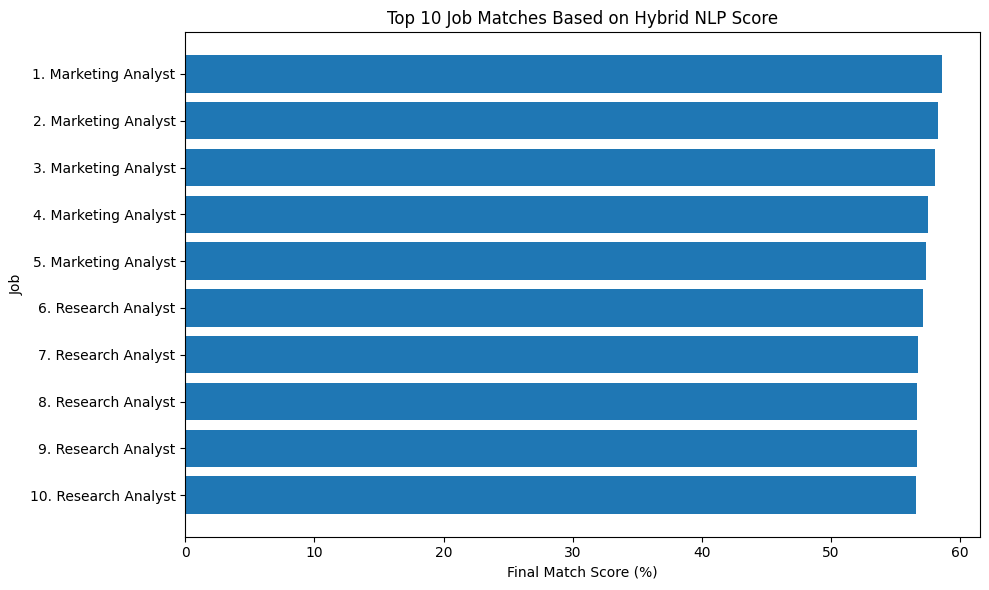

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

labels = [
    f"{i+1}. {row['Job Title']}"
    for i, (_, row) in enumerate(top_10.iterrows())
]

scores = top_10["final_match_score"]

plt.barh(labels[::-1], scores[::-1])

plt.xlabel("Final Match Score (%)")
plt.ylabel("Job")
plt.title("Top 10 Job Matches Based on Hybrid NLP Score")

plt.tight_layout()
plt.show()

In [75]:
test_resumes = {
    "Data Analyst": """
    Data Analyst with experience in Python, SQL, Excel, Power BI and Tableau.
    Skilled in data cleaning, statistical analysis, data visualization,
    machine learning and dashboard development.
    Strong analytical, communication and problem-solving skills.
    """,

    "Marketing Analyst": """
    Marketing Analyst with experience in digital marketing, social media,
    SEO, Google Analytics, data analysis and marketing campaigns.
    Skilled in Excel, Power BI, data visualization and communication.
    Experienced in analyzing customer data and generating marketing insights.
    """,

    "Software Developer": """
    Software Developer with experience in Python, Java, JavaScript, HTML, CSS
    and React. Skilled in software development, web development, databases,
    APIs and debugging. Experienced in building applications and solving
    technical problems.
    """
}

print("Number of test resumes:", len(test_resumes))

for name in test_resumes:
    print("\n", name)
    print(test_resumes[name])

Number of test resumes: 3

 Data Analyst

    Data Analyst with experience in Python, SQL, Excel, Power BI and Tableau.
    Skilled in data cleaning, statistical analysis, data visualization,
    machine learning and dashboard development.
    Strong analytical, communication and problem-solving skills.
    

 Marketing Analyst

    Marketing Analyst with experience in digital marketing, social media,
    SEO, Google Analytics, data analysis and marketing campaigns.
    Skilled in Excel, Power BI, data visualization and communication.
    Experienced in analyzing customer data and generating marketing insights.
    

 Software Developer

    Software Developer with experience in Python, Java, JavaScript, HTML, CSS
    and React. Skilled in software development, web development, databases,
    APIs and debugging. Experienced in building applications and solving
    technical problems.
    


In [76]:
# Step 19: Evaluate multiple test resumes

test_results = {}

for resume_name, resume_text in test_resumes.items():

    # 1. TF-IDF retrieval
    resume_tfidf = tfidf.transform([resume_text])

    similarities = cosine_similarity(
        resume_tfidf,
        tfidf_matrix
    ).flatten()

    top_indices = similarities.argsort()[-20:][::-1]

    candidates = df_unique.iloc[top_indices].copy()

    candidates["tfidf_score"] = (
        similarities[top_indices] * 100
    )

    # 2. Semantic similarity
    candidate_texts = candidates["model_text"].tolist()

    candidate_embeddings = model.encode(
        candidate_texts,
        convert_to_tensor=True,
        show_progress_bar=False
    )

    resume_embedding_test = model.encode(
        resume_text,
        convert_to_tensor=True
    )

    semantic_scores = util.cos_sim(
        resume_embedding_test,
        candidate_embeddings
    ).cpu().numpy().flatten() * 100

    candidates["semantic_score"] = semantic_scores

    # 3. Skill matching
    resume_skills = set(
        extract_normalized_skills(
            resume_text,
            skill_aliases
        )
    )

    def calculate_test_skill_score(job_text):
        job_skills = set(
            extract_normalized_skills(
                job_text,
                skill_aliases
            )
        )

        if len(job_skills) == 0:
            return 0

        matched = resume_skills.intersection(job_skills)

        return (len(matched) / len(job_skills)) * 100

    candidates["skill_score"] = candidates[
        "model_text"
    ].apply(calculate_test_skill_score)

    # 4. Hybrid score
    candidates["final_match_score"] = (
        0.30 * candidates["tfidf_score"] +
        0.40 * candidates["semantic_score"] +
        0.30 * candidates["skill_score"]
    )

    # 5. Rank
    candidates = candidates.sort_values(
        "final_match_score",
        ascending=False
    ).reset_index(drop=True)

    test_results[resume_name] = candidates

print("Testing completed successfully!")

Testing completed successfully!


In [77]:
for resume_name, results in test_results.items():
    print("\n" + "=" * 70)
    print(f"TOP 5 RESULTS — {resume_name}")
    print("=" * 70)

    display(
        results[
            [
                "Job Title",
                "Role",
                "tfidf_score",
                "semantic_score",
                "skill_score",
                "final_match_score"
            ]
        ].head(5)
    )


TOP 5 RESULTS — Data Analyst


,Job Title,Role,tfidf_score,semantic_score,skill_score,final_match_score
0,Marketing Analyst,Data Analyst,27.318789,69.039848,85.714286,61.525862
1,Marketing Analyst,Data Analyst,27.318789,68.257370,85.714286,61.212870
2,Marketing Analyst,Data Analyst,27.260896,67.638794,85.714286,60.948072
3,Marketing Analyst,Data Analyst,27.318789,65.282417,85.714286,60.022889
4,Marketing Analyst,Data Analyst,27.318789,64.588974,85.714286,59.745513



TOP 5 RESULTS — Marketing Analyst


,Job Title,Role,tfidf_score,semantic_score,skill_score,final_match_score
0,Marketing Analyst,Digital Marketing Analyst,31.426641,67.551193,100.0,66.448470
1,Marketing Analyst,Digital Marketing Analyst,31.426641,66.705475,100.0,66.110182
2,Marketing Analyst,Digital Marketing Analyst,31.369467,66.444473,100.0,65.988630
3,Marketing Analyst,Digital Marketing Analyst,31.369556,66.231079,100.0,65.903298
4,Marketing Analyst,Digital Marketing Analyst,31.426641,66.089775,100.0,65.863904



TOP 5 RESULTS — Software Developer


,Job Title,Role,tfidf_score,semantic_score,skill_score,final_match_score
0,Software Engineer,Frontend Developer,22.650425,65.520073,0,33.003156
1,Software Engineer,Frontend Developer,22.650425,64.361595,0,32.539766
2,Software Engineer,Frontend Developer,22.616806,62.924118,0,31.954689
3,Software Engineer,Frontend Developer,22.616806,62.735588,0,31.879278
4,Software Engineer,Frontend Developer,22.650425,62.257027,0,31.697938


In [78]:
import pandas as pd

evaluation_summary = []

for resume_name, results in test_results.items():
    top_5 = results.head(5)

    evaluation_summary.append({
        "Test Resume": resume_name,
        "Top Job Title": top_5.iloc[0]["Job Title"],
        "Top Role": top_5.iloc[0]["Role"],
        "Top Match Score (%)": round(
            top_5.iloc[0]["final_match_score"], 2
        ),
        "Average Top-5 Score (%)": round(
            top_5["final_match_score"].mean(), 2
        )
    })

evaluation_df = pd.DataFrame(evaluation_summary)

display(evaluation_df)

,Test Resume,Top Job Title,Top Role,Top Match Score (%),Average Top-5 Score (%)
0,Data Analyst,Marketing Analyst,Data Analyst,61.53,60.69
1,Marketing Analyst,Marketing Analyst,Digital Marketing Analyst,66.45,66.06
2,Software Developer,Software Engineer,Frontend Developer,33.00,32.21


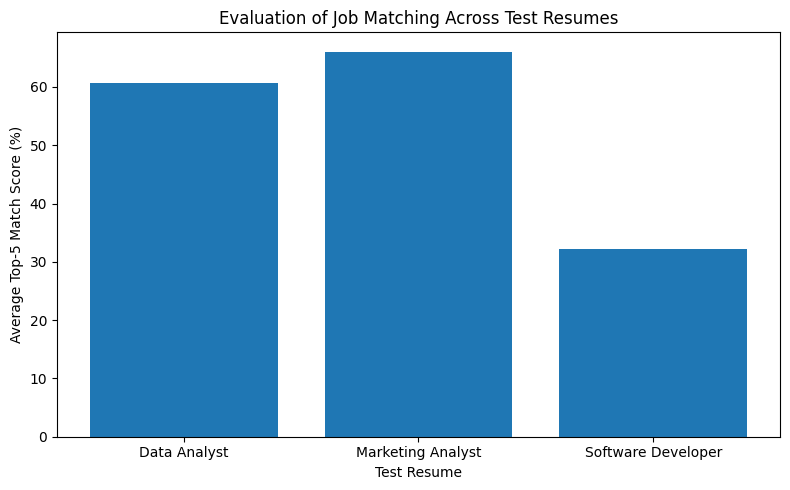

In [79]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    evaluation_df["Test Resume"],
    evaluation_df["Average Top-5 Score (%)"]
)

plt.xlabel("Test Resume")
plt.ylabel("Average Top-5 Match Score (%)")
plt.title("Evaluation of Job Matching Across Test Resumes")

plt.tight_layout()
plt.show()

In [80]:
def match_resume_to_jobs(resume_text, top_n=5):

    # --------------------------------
    # 1. TF-IDF retrieval
    # --------------------------------
    resume_tfidf = tfidf.transform([resume_text])

    similarities = cosine_similarity(
        resume_tfidf,
        tfidf_matrix
    ).flatten()

    top_indices = similarities.argsort()[-20:][::-1]

    candidates = df_unique.iloc[top_indices].copy()

    candidates["tfidf_score"] = (
        similarities[top_indices] * 100
    )

    # --------------------------------
    # 2. Semantic similarity
    # --------------------------------
    candidate_texts = candidates["model_text"].tolist()

    candidate_embeddings = model.encode(
        candidate_texts,
        convert_to_tensor=True,
        show_progress_bar=False
    )

    resume_embedding = model.encode(
        resume_text,
        convert_to_tensor=True
    )

    semantic_scores = util.cos_sim(
        resume_embedding,
        candidate_embeddings
    ).cpu().numpy().flatten() * 100

    candidates["semantic_score"] = semantic_scores

    # --------------------------------
    # 3. Skill matching
    # --------------------------------
    resume_skills = set(
        extract_normalized_skills(
            resume_text,
            skill_aliases
        )
    )

    skill_scores = []
    matched_skills_list = []
    missing_skills_list = []

    for job_text in candidates["model_text"]:

        job_skills = set(
            extract_normalized_skills(
                job_text,
                skill_aliases
            )
        )

        if len(job_skills) == 0:
            skill_score = 0
        else:
            matched = resume_skills & job_skills
            skill_score = (
                len(matched) / len(job_skills)
            ) * 100

        matched_skills_list.append(
            sorted(resume_skills & job_skills)
        )

        missing_skills_list.append(
            sorted(job_skills - resume_skills)
        )

        skill_scores.append(skill_score)

    candidates["skill_score"] = skill_scores
    candidates["matched_skills"] = matched_skills_list
    candidates["missing_skills"] = missing_skills_list

    # --------------------------------
    # 4. Hybrid score
    # --------------------------------
    candidates["final_match_score"] = (
        0.30 * candidates["tfidf_score"] +
        0.40 * candidates["semantic_score"] +
        0.30 * candidates["skill_score"]
    )

    # --------------------------------
    # 5. Rank jobs
    # --------------------------------
    results = candidates.sort_values(
        by="final_match_score",
        ascending=False
    ).reset_index(drop=True)

    return results.head(top_n)

In [81]:
final_demo = match_resume_to_jobs(
    sample_resume,
    top_n=5
)

display(
    final_demo[
        [
            "Job Title",
            "Role",
            "tfidf_score",
            "semantic_score",
            "skill_score",
            "final_match_score",
            "matched_skills",
            "missing_skills"
        ]
    ]
)

,Job Title,Role,tfidf_score,semantic_score,skill_score,final_match_score,matched_skills,missing_skills
0,Marketing Analyst,Data Analyst,27.806942,72.067055,71.428571,58.597476,"[communication, data visualization, power bi, ...","[data analysis, tableau]"
1,Marketing Analyst,Data Analyst,27.806942,71.202156,71.428571,58.251518,"[communication, data visualization, power bi, ...","[data analysis, tableau]"
2,Marketing Analyst,Data Analyst,27.748015,70.683304,71.428571,58.026297,"[communication, data visualization, power bi, ...","[data analysis, tableau]"
3,Marketing Analyst,Data Analyst,27.806942,69.409584,71.428571,57.534488,"[communication, data visualization, power bi, ...","[data analysis, tableau]"
4,Marketing Analyst,Data Analyst,27.806942,68.854836,71.428571,57.312589,"[communication, data visualization, power bi, ...","[data analysis, tableau]"
